# 1. Experiment Introduction

## Experiment Objectives

(1) Deeply understand the meaning of machine learning and the basic workflow for solving machine learning tasks;

(2) Learn to use Python programming language and machine learning libraries (e.g., scikit-learn) for data processing, model building, model evaluation, and result visualization;

(3) Understand the basic concepts and principles of linear regression models;

(4) Understand the evaluation metrics for linear regression models (Root Mean Square Error and Coefficient of Determination);

(5) Master how to use linear regression models to analyze Chinese fir planting density and build a model that predicts approximate growth diameter simply from planting density.

## Experiment Content

This experiment focuses on forestry planting density analysis. Different planting densities lead to variations in Chinese fir growth diameter. The dataset contains growth diameter data under various density conditions. Data information is as follows:

<font color="red">- Column A: density</font>

<font color="red">- Column B: diameter</font>


## Experiment Principle

Linear regression is a supervised learning algorithm used to establish a linear relationship between input features (independent variables) and output target (dependent variable). Its core formula is:

**y = w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ**

where w₀ is the intercept, w₁, w₂, ..., wₙ are feature coefficients, x₁, x₂, ..., xₙ are input features, and y is the predicted target variable.

<font color="red">In this experiment, planting density (Column A) is the input feature and Chinese fir diameter (Column B) is the output target. The linear regression model is fitted by minimizing the mean squared error between predicted and actual values, thereby determining optimal model parameters. The test set is used to validate the model's prediction performance.</font>

## Experiment Environment

- Python 3.10.16
- numpy 1.26.4
- pandas 2.2.3
- matplotlib 3.10.0
- scikit-learn 1.6.1

## Experiment Steps
<font color="red">
    
(1) Load data

(2) Separate feature variables (X) and target variable (y)

(3) Split dataset: training set (**80%**) and test set (**20%**)

(4) Build and train machine learning model

(5) Test and evaluate machine learning model (**i.e., MSE, R²**)

(6) Visualize experimental results

</font>
---

# 2. Experiment Requirements

## 2.1 Data and Result Visualization

<font color="red">- Draw a scatter plot of data (density vs. diameter) to observe data distribution patterns;</font>

<font color="red">- Draw a scatter plot of training set data points and test set data points, along with the fitted regression line;</font>

<font color="red">- Draw a scatter plot of actual values vs. predicted values for each sample in the test set;</font>

<font color="red">- Draw a scatter plot of predicted values vs. residuals (i.e., true y - predicted y) for each sample in the test set.</font>


Data preview:
   density  diameter
0       41      29.1
1       41      28.4
2       41      27.4
3       41      25.7
4       42      27.4

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   density   210 non-null    int64  
 1   diameter  210 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 3.4 KB
None


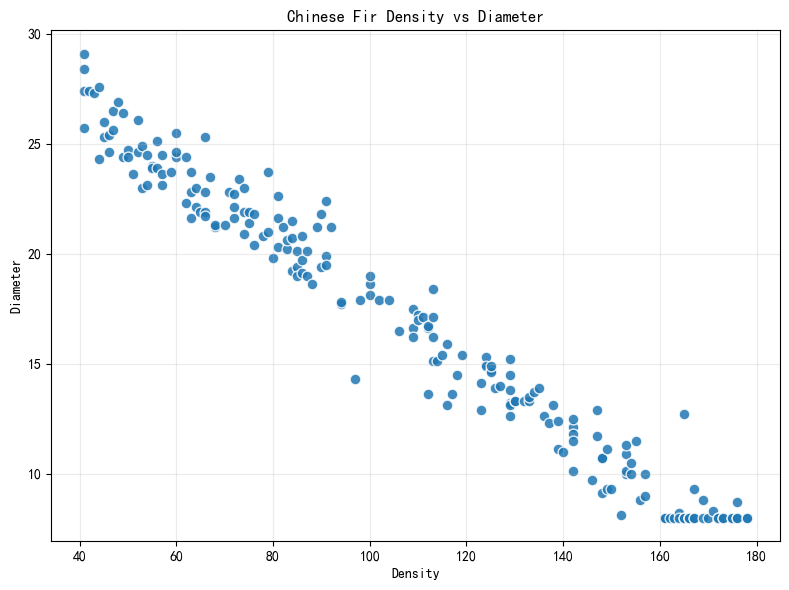

Training samples: 168
Test samples: 42

Model parameters:
Intercept: 32.443858
Coefficient: -0.144849

Test set evaluation:
MSE: 0.821670
R2: 0.974920


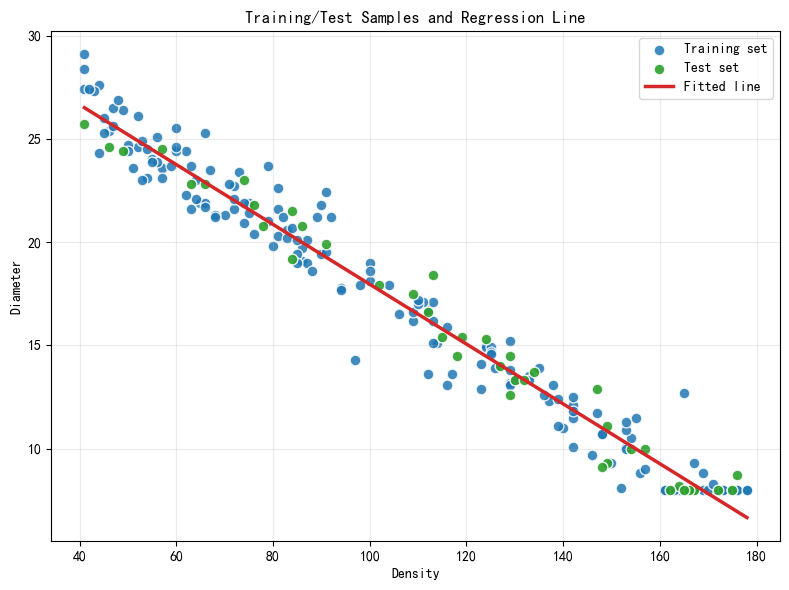

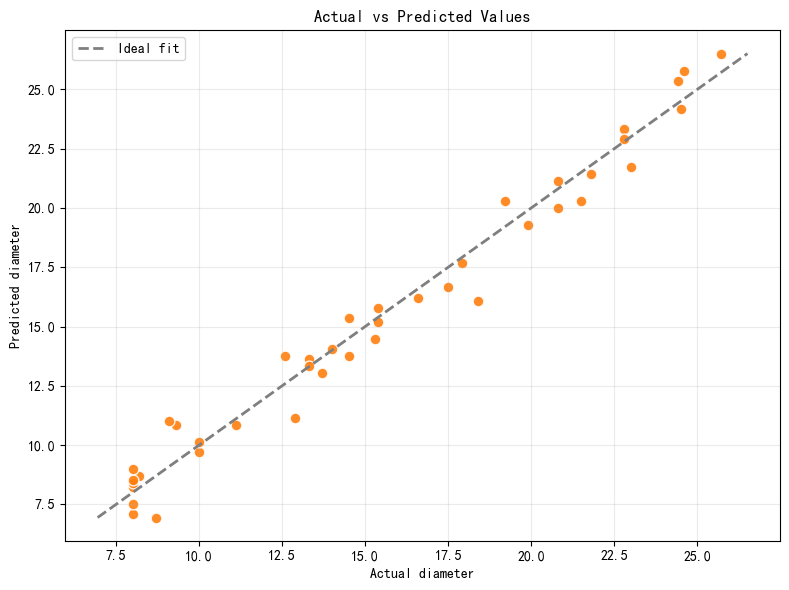

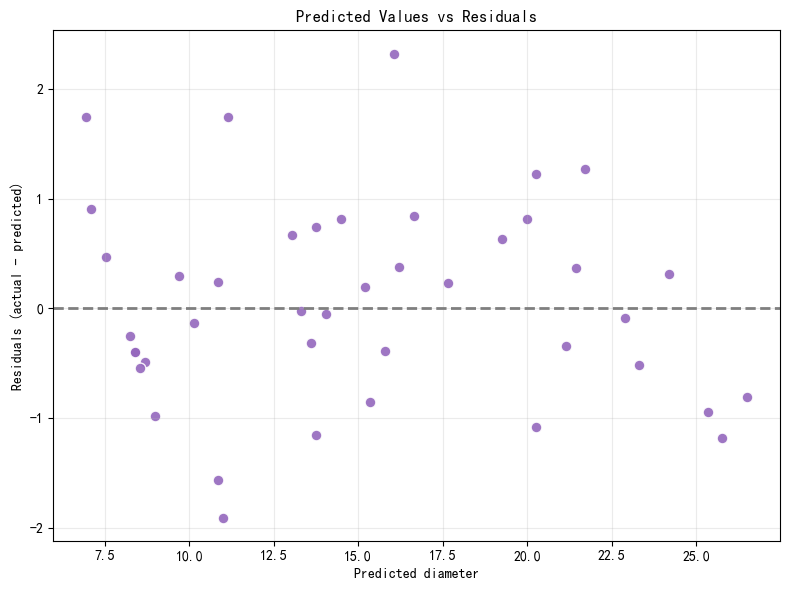

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 1. Load data
df = pd.read_csv('tree.csv')
print('Data preview:')
print(df.head())
print('\nBasic info:')
print(df.info())

# 2. Separate features and target
X = df[['density']]
y = df['diameter']

# 3. Visualize the full dataset
plt.figure(figsize=(8, 6))
plt.scatter(df['density'], df['diameter'], color='#1f77b4', alpha=0.85, edgecolors='white', s=60)
plt.title('Chinese Fir Density vs Diameter')
plt.xlabel('Density')
plt.ylabel('Diameter')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 4. Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')

# 5. Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

print('\nModel parameters:')
print(f'Intercept: {model.intercept_:.6f}')
print(f'Coefficient: {model.coef_[0]:.6f}')

# 6. Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('\nTest set evaluation:')
print(f'MSE: {mse:.6f}')
print(f'R2: {r2:.6f}')

# 7. Plot training data, test data, and fitted regression line
x_line = pd.DataFrame({'density': [df['density'].min(), df['density'].max()]})
y_line = model.predict(x_line)

plt.figure(figsize=(8, 6))
plt.scatter(X_train['density'], y_train, color='#1f77b4', alpha=0.85, label='Training set', edgecolors='white', s=60)
plt.scatter(X_test['density'], y_test, color='#2ca02c', alpha=0.9, label='Test set', edgecolors='white', s=60)
plt.plot(x_line['density'], y_line, color='#d62728', linewidth=2.5, label='Fitted line')
plt.title('Training/Test Samples and Regression Line')
plt.xlabel('Density')
plt.ylabel('Diameter')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 8. Plot actual values versus predicted values on the test set
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='#ff7f0e', alpha=0.9, edgecolors='white', s=60)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#7f7f7f', linestyle='--', linewidth=2, label='Ideal fit')
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual diameter')
plt.ylabel('Predicted diameter')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 9. Plot predicted values versus residuals on the test set
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='#9467bd', alpha=0.9, edgecolors='white', s=60)
plt.axhline(0, color='#7f7f7f', linestyle='--', linewidth=2)
plt.title('Predicted Values vs Residuals')
plt.xlabel('Predicted diameter')
plt.ylabel('Residuals (actual - predicted)')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()